# 05 - Controlled Baseline Model Training & Benchmark
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Implement, train, and benchmark four controlled spatio-temporal deep learning architectures under identical conditions on the speaker-independent Tai Phake digits dataset:
1. **CNN-LSTM** (Unidirectional LSTM)
2. **CNN-BiLSTM** (Bidirectional LSTM)
3. **CNN-GRU** (Unidirectional GRU)
4. **CNN-BiGRU** (Bidirectional GRU)

### Experimental Controls:
- Identical 24/3/3 speaker split (Test: `s1`, `s4`, `s21`)
- Identical frame sequences ($T=30$, $96\times 96\times 3$)
- Identical optimizer: Adam($10^{-4}$), loss: SparseCategoricalCrossentropy
- `EarlyStopping(patience=15, restore_best_weights=True)` monitoring `val_loss`
- `ModelCheckpoint` saving `best_model.keras`
- **Evaluation on TEST set is conducted ONLY after best checkpoint selection on validation data**.

## 1. Imports & Environment Setup

In [11]:
# Section 1: Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


## 2. Configuration & Dataset Loading
Loads the preprocessed manifest and builds the high-throughput `tf.data` datasets with in-memory caching.

In [ ]:
# Section 2: Configuration & DataLoader
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# Dataset directories: easily switchable by pointing or replacing data/processed/train, val, test
DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

RESULTS_DIR = PROJECT_ROOT / "results" / "dlib"
MODELS_DIR = PROJECT_ROOT / "results" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 11
NUM_FRAMES = 30
TARGET_SIZE = 96
BATCH_SIZE = 32
CNN_FEATURE_DIM = 256
RNN_HIDDEN = 256
RNN_LAYERS = 2
DROPOUT = 0.5
LR = 3e-4
MAX_EPOCHS = 80
PATIENCE = 15

# NUM_CLASSES = 11
# NUM_FRAMES = 30
# TARGET_WIDTH = 96
# TARGET_HEIGHT = 96
# CHANNELS = 3
# BATCH_SIZE = 16

# CNN_FEATURE_DIM = 64
# RNN_HIDDEN_UNITS = 64
# RNN_LAYERS = 1
# DROPOUT_RATE = 0.3
# LEARNING_RATE = 1e-4
# MAX_EPOCHS = 100
# PATIENCE = 15
RE_TRAIN = False  # Set to True to re-train all models from scratch

EXPECTED_DIGITS = [f"d{i}" for i in range(11)]
CLASS_TO_ID = {d: i for i, d in enumerate(EXPECTED_DIGITS)}
ID_TO_CLASS = {i: d for i, d in enumerate(EXPECTED_DIGITS)}

def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

def sample_frame_paths(fpaths, target=NUM_FRAMES):
    n = len(fpaths)
    return [str(fpaths[i]) for i in np.round(np.linspace(0, n - 1, target)).astype(int)]

def load_single_frame(path_tensor):
    raw = tf.io.read_file(path_tensor)
    img = tf.image.decode_jpeg(raw, channels=CHANNELS)
    img = tf.image.resize(img, [TARGET_HEIGHT, TARGET_WIDTH], method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([TARGET_HEIGHT, TARGET_WIDTH, CHANNELS])
    return img

def load_video_frames(paths_tensor):
    frames = tf.map_fn(
        fn=load_single_frame,
        elems=paths_tensor,
        fn_output_signature=tf.TensorSpec(shape=[TARGET_HEIGHT, TARGET_WIDTH, CHANNELS], dtype=tf.float32)
    )
    frames.set_shape([NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS])
    return frames

def index_split_utterances(split_dir, split_name):
    records = []
    speakers = sorted([d.name for d in split_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    for spk in speakers:
        for digit in EXPECTED_DIGITS:
            ddir = split_dir / spk / digit
            if not ddir.exists():
                continue
            fpaths = sorted([f for f in ddir.glob('*.jpg')], key=natural_sort_key)
            if len(fpaths) > 0:
                records.append({
                    'speaker': spk,
                    'digit': digit,
                    'frame_paths': sample_frame_paths(fpaths, NUM_FRAMES),
                    'digit_id': CLASS_TO_ID[digit],
                    'split': split_name
                })
    return pd.DataFrame(records)

train_df = index_split_utterances(TRAIN_DIR, 'train')
val_df = index_split_utterances(VAL_DIR, 'val')
test_df = index_split_utterances(TEST_DIR, 'test')

def create_tf_dataset_from_records(df_subset, is_training=False, shuffle=True):
    all_paths = list(df_subset['frame_paths'])
    all_labels = list(df_subset['digit_id'])
    ds = tf.data.Dataset.from_tensor_slices((all_paths, all_labels))
    ds = ds.map(lambda p, l: (load_video_frames(p), tf.cast(l, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if is_training and shuffle:
        ds = ds.shuffle(len(df_subset), seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = create_tf_dataset_from_records(train_df, is_training=True, shuffle=True)
val_dataset = create_tf_dataset_from_records(val_df, is_training=False, shuffle=False)
test_dataset = create_tf_dataset_from_records(test_df, is_training=False, shuffle=False)

print(f"Loaded from: Train={TRAIN_DIR}, Val={VAL_DIR}, Test={TEST_DIR}")
print(f"Speakers: {train_df['speaker'].nunique()} train, {val_df['speaker'].nunique()} val, {test_df['speaker'].nunique()} test")
print(f"Utterances: {len(train_df)} train, {len(val_df)} val, {len(test_df)} test")
print(f"Batches: {len(train_dataset)} train | {len(val_dataset)} val | {len(test_dataset)} test")


train_dataset: 69 batches | val: 3 | test: 5


## 3. Controlled Model Architectures
We construct lightweight CNN backbones coupled with recurrent sequence aggregators (LSTM, BiLSTM, GRU, BiGRU).

In [13]:
# Section 3: Model Builder
def build_controlled_model(
    model_type="cnn_lstm",
    input_shape=(NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS),
    cnn_feature_dim=CNN_FEATURE_DIM,
    rnn_units=RNN_HIDDEN_UNITS,
    rnn_layers=RNN_LAYERS,
    dropout_rate=DROPOUT_RATE,
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE
):
    inputs = tf.keras.layers.Input(shape=input_shape, name="lip_sequence_input")
    cnn = tf.keras.Sequential([
        tf.keras.layers.Conv2D(16, (3, 3), strides=(2, 2), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(cnn_feature_dim, activation="relu")
    ], name="lightweight_cnn")

    x = tf.keras.layers.TimeDistributed(cnn, name="time_distributed_cnn")(inputs)

    m_type = model_type.lower()
    for layer_idx in range(rnn_layers):
        return_sequences = (layer_idx < rnn_layers - 1)
        if m_type == "cnn_bilstm":
            r_layer = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(rnn_units, return_sequences=return_sequences), name=f"bilstm_{layer_idx+1}")
        elif m_type == "cnn_lstm":
            r_layer = tf.keras.layers.LSTM(rnn_units, return_sequences=return_sequences, name=f"lstm_{layer_idx+1}")
        elif m_type == "cnn_bigru":
            r_layer = tf.keras.layers.Bidirectional(tf.keras.layers.GRU(rnn_units, return_sequences=return_sequences), name=f"bigru_{layer_idx+1}")
        elif m_type == "cnn_gru":
            r_layer = tf.keras.layers.GRU(rnn_units, return_sequences=return_sequences, name=f"gru_{layer_idx+1}")
        else:
            raise ValueError(f"Unknown model_type: {model_type}")
        x = r_layer(x)

    x = tf.keras.layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="digit_classifier")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"vsr_{m_type}")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    return model

print("Controlled Architecture Parameters Summary:")
for m_name in ["cnn_lstm", "cnn_bilstm", "cnn_gru", "cnn_bigru"]:
    m = build_controlled_model(m_name)
    print(f"  {m_name.upper():<12}: Parameters = {m.count_params():,}")

Controlled Architecture Parameters Summary:
  CNN_LSTM    : Parameters = 61,931
  CNN_BILSTM  : Parameters = 95,659
  CNN_GRU     : Parameters = 53,867
  CNN_BIGRU   : Parameters = 79,531


## 4. Controlled Experiment Execution: Four Models
We train and benchmark each of the four models under identical conditions, saving all metrics, confusion matrices, and model weights.


          BASELINE EXPERIMENT: CNN_LSTM
Training cnn_lstm from scratch (max 100 epochs, patience 15)...
Epoch 1/100


/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.0855 - loss: 2.4009 - val_accuracy: 0.1136 - val_loss: 2.4000
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.1082 - loss: 2.3899 - val_accuracy: 0.1364 - val_loss: 2.3933
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.1336 - loss: 2.3735 - val_accuracy: 0.0909 - val_loss: 2.3874
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.1545 - loss: 2.3427 - val_accuracy: 0.1591 - val_loss: 2.3829
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.1609 - loss: 2.3035 - val_accuracy: 0.1818 - val_loss: 2.3698
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.1864 - loss: 2.2522 - val_accuracy: 0.1136 - val_loss: 2.4458
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.1882 - loss: 2.2212 - val_accuracy: 0.1364 - val_loss: 2.4192
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.1973 - loss: 2.1746 - val_accuracy: 0.1

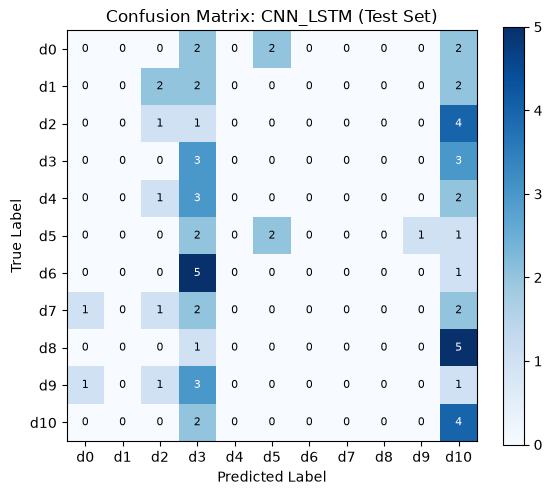


          BASELINE EXPERIMENT: CNN_BILSTM
Training cnn_bilstm from scratch (max 100 epochs, patience 15)...
Epoch 1/100


/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - accuracy: 0.0991 - loss: 2.3999 - val_accuracy: 0.1136 - val_loss: 2.3994
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.1318 - loss: 2.3788 - val_accuracy: 0.1364 - val_loss: 2.3815
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.1509 - loss: 2.3449 - val_accuracy: 0.1136 - val_loss: 2.3572
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.1845 - loss: 2.2978 - val_accuracy: 0.1136 - val_loss: 2.3274
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.1991 - loss: 2.2424 - val_accuracy: 0.1591 - val_loss: 2.2902
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.2245 - loss: 2.1837 - val_accuracy: 0.1591 - val_loss: 2.3360
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.2564 - loss: 2.1169 - val_accuracy: 0.1364 - val_loss: 2.3134
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.2782 - loss: 2.0803 - val_accuracy: 0.1

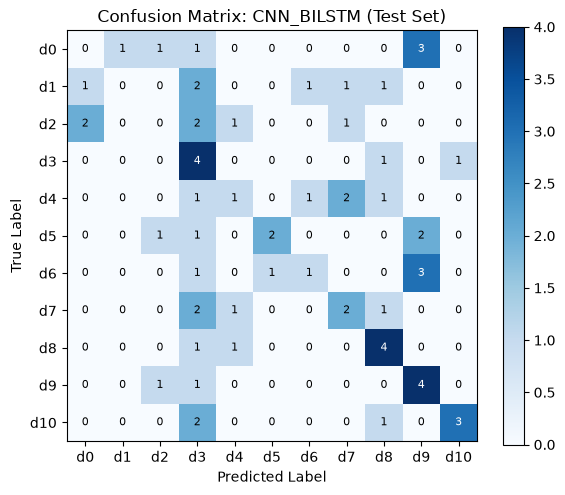


          BASELINE EXPERIMENT: CNN_GRU
Training cnn_gru from scratch (max 100 epochs, patience 15)...
Epoch 1/100


/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.0845 - loss: 2.4070 - val_accuracy: 0.1364 - val_loss: 2.4024
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.1091 - loss: 2.3941 - val_accuracy: 0.1818 - val_loss: 2.4031
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.1373 - loss: 2.3855 - val_accuracy: 0.1364 - val_loss: 2.4056
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.1427 - loss: 2.3782 - val_accuracy: 0.1364 - val_loss: 2.4066
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.1400 - loss: 2.3723 - val_accuracy: 0.1364 - val_loss: 2.4160
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.1600 - loss: 2.3621 - val_accuracy: 0.1364 - val_loss: 2.4323
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.1564 - loss: 2.3518 - val_accuracy: 0.1364 - val_loss: 2.4453
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.1364 - loss: 2.3486 - val_accuracy: 0.136

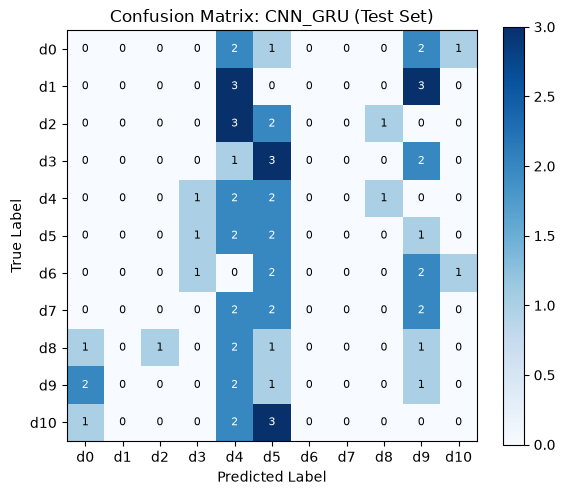


          BASELINE EXPERIMENT: CNN_BIGRU
Training cnn_bigru from scratch (max 100 epochs, patience 15)...
Epoch 1/100


/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step - accuracy: 0.1164 - loss: 2.3995 - val_accuracy: 0.1364 - val_loss: 2.4104
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.1145 - loss: 2.3876 - val_accuracy: 0.1136 - val_loss: 2.4119
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.1291 - loss: 2.3789 - val_accuracy: 0.1364 - val_loss: 2.4061
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.1345 - loss: 2.3682 - val_accuracy: 0.1364 - val_loss: 2.4049
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.1591 - loss: 2.3604 - val_accuracy: 0.1136 - val_loss: 2.4081
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.1691 - loss: 2.3443 - val_accuracy: 0.0909 - val_loss: 2.4099
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.1809 - loss: 2.3277 - val_accuracy: 0.0909 - val_loss: 2.4101
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.2018 - loss: 2.2940 - val_accuracy: 0

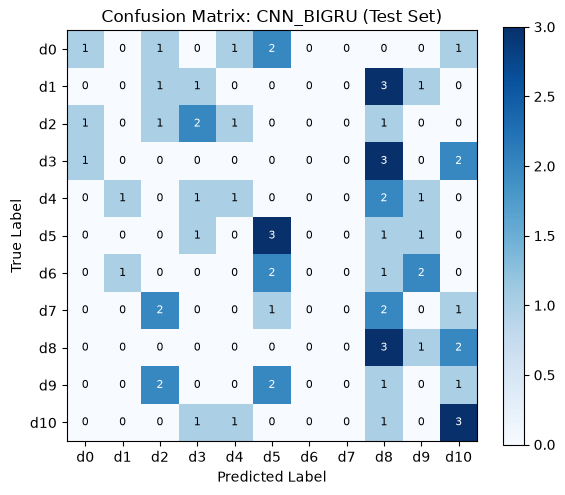

In [14]:
# Section 4: Training & Evaluation Loop
MODELS_TO_RUN = ["cnn_lstm", "cnn_bilstm", "cnn_gru", "cnn_bigru"]
experiment_results = []

for m_name in MODELS_TO_RUN:
    print("\n" + "=" * 75)
    print(f"          BASELINE EXPERIMENT: {m_name.upper()}")
    print("=" * 75)

    model_save_dir = MODELS_DIR / m_name
    model_save_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = model_save_dir / "best_model.keras"
    hist_csv_path = model_save_dir / "training_history.csv"
    metrics_json_path = model_save_dir / "metrics.json"

    if not best_model_path.exists() or RE_TRAIN:
        print(f"Training {m_name} from scratch (max {MAX_EPOCHS} epochs, patience {PATIENCE})...")
        tf.keras.backend.clear_session()
        random.seed(SEED)
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model = build_controlled_model(m_name)
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(filepath=str(best_model_path), monitor="val_loss", save_best_only=True, verbose=0)
        ]
        t0 = time.time()
        history = model.fit(train_dataset, validation_data=val_dataset, epochs=MAX_EPOCHS, callbacks=callbacks, verbose=1)
        hist_df = pd.DataFrame(history.history)
        hist_df.index.name = "epoch"
        hist_df.to_csv(hist_csv_path)
    else:
        print(f"Loading existing best checkpoint for {m_name} from: {best_model_path.resolve()}")
        hist_df = pd.read_csv(hist_csv_path, index_col="epoch")

    # Evaluate on TEST set only with selected checkpoint
    best_model = tf.keras.models.load_model(str(best_model_path))
    y_true_list, y_pred_list, y_prob_list = [], [], []
    for x_b, y_b in test_dataset:
        preds = best_model.predict(x_b, verbose=0)
        y_prob_list.extend(preds)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(y_b.numpy())

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_prob = np.array(y_prob_list)

    test_acc = float(accuracy_score(y_true, y_pred))
    test_macro_prec = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    test_macro_rec = float(recall_score(y_true, y_pred, average="macro", zero_division=0))
    test_macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    per_class_prec = precision_score(y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_rec = recall_score(y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0).tolist()
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    print(f"\nTest Performance Metrics ({m_name.upper()}):")
    print(f"  Accuracy:        {test_acc:.4f}")
    print(f"  Macro Precision: {test_macro_prec:.4f}")
    print(f"  Macro Recall:    {test_macro_rec:.4f}")
    print(f"  Macro F1:        {test_macro_f1:.4f}")

    # Save predictions.csv
    pred_df = test_df.copy()
    pred_df["true_label"] = y_true
    pred_df["predicted_label"] = y_pred
    pred_df["predicted_digit"] = [ID_TO_CLASS[idx] for idx in y_pred]
    pred_df["correct"] = (y_true == y_pred)
    for cls_idx in range(NUM_CLASSES):
        pred_df[f"prob_d{cls_idx}"] = y_prob[:, cls_idx]
    pred_df.to_csv(model_save_dir / "predictions.csv", index=False)

    # Save metrics.json
    metrics_data = {
        "model": m_name,
        "epochs_trained": len(hist_df),
        "best_epoch": int(np.argmin(hist_df["val_loss"]) + 1),
        "best_val_loss": float(np.min(hist_df["val_loss"])),
        "best_val_accuracy": float(hist_df["val_accuracy"].iloc[np.argmin(hist_df["val_loss"])]),
        "test_accuracy": test_acc,
        "test_macro_precision": test_macro_prec,
        "test_macro_recall": test_macro_rec,
        "test_macro_f1": test_macro_f1,
        "per_class": {f"d{i}": {"precision": float(per_class_prec[i]), "recall": float(per_class_rec[i]), "f1": float(per_class_f1[i]), "support": int(np.sum(y_true == i))} for i in range(NUM_CLASSES)},
        "confusion_matrix": cm.tolist()
    }
    with open(metrics_json_path, "w") as f:
        json.dump(metrics_data, f, indent=2)

    # Plot & Save Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(NUM_CLASSES), yticks=np.arange(NUM_CLASSES), xticklabels=EXPECTED_DIGITS, yticklabels=EXPECTED_DIGITS,
           title=f"Confusion Matrix: {m_name.upper()} (Test Set)", ylabel="True Label", xlabel="Predicted Label")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = cm[i, j]
            color = "white" if val > cm.max() / 2 else "black"
            ax.text(j, i, format(val, "d"), ha="center", va="center", color=color, fontsize=8)
    plt.tight_layout()
    plt.savefig(model_save_dir / "confusion_matrix.png", dpi=150)
    plt.show()

    # Save config.json
    config_data = {
        "model_type": m_name,
        "input_shape": [NUM_FRAMES, TARGET_HEIGHT, TARGET_WIDTH, CHANNELS],
        "cnn_feature_dim": CNN_FEATURE_DIM,
        "rnn_units": RNN_HIDDEN_UNITS,
        "rnn_layers": RNN_LAYERS,
        "dropout": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": PATIENCE,
        "optimizer": "Adam",
        "loss": "SparseCategoricalCrossentropy",
        "parameters_count": int(best_model.count_params())
    }
    with open(model_save_dir / "config.json", "w") as f:
        json.dump(config_data, f, indent=2)

    experiment_results.append({
        "model": m_name,
        "test_accuracy": test_acc,
        "test_macro_precision": test_macro_prec,
        "test_macro_recall": test_macro_rec,
        "test_macro_f1": test_macro_f1
    })

## 5. Model Comparison & Trajectory Visualization
Consolidated benchmark table and comparative training/validation loss and accuracy trajectories.

             CONTROLLED BASELINE BENCHMARK SUMMARY (TEST SET)
     model  test_accuracy  test_macro_precision  test_macro_recall  test_macro_f1
  cnn_lstm       0.151515              0.084564           0.151515       0.090599
cnn_bilstm       0.318182              0.303030           0.318182       0.282828
   cnn_gru       0.075758              0.024721           0.075758       0.037104
 cnn_bigru       0.181818              0.135714           0.181818       0.143279

Saved comparison CSV to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/models/model_comparison.csv


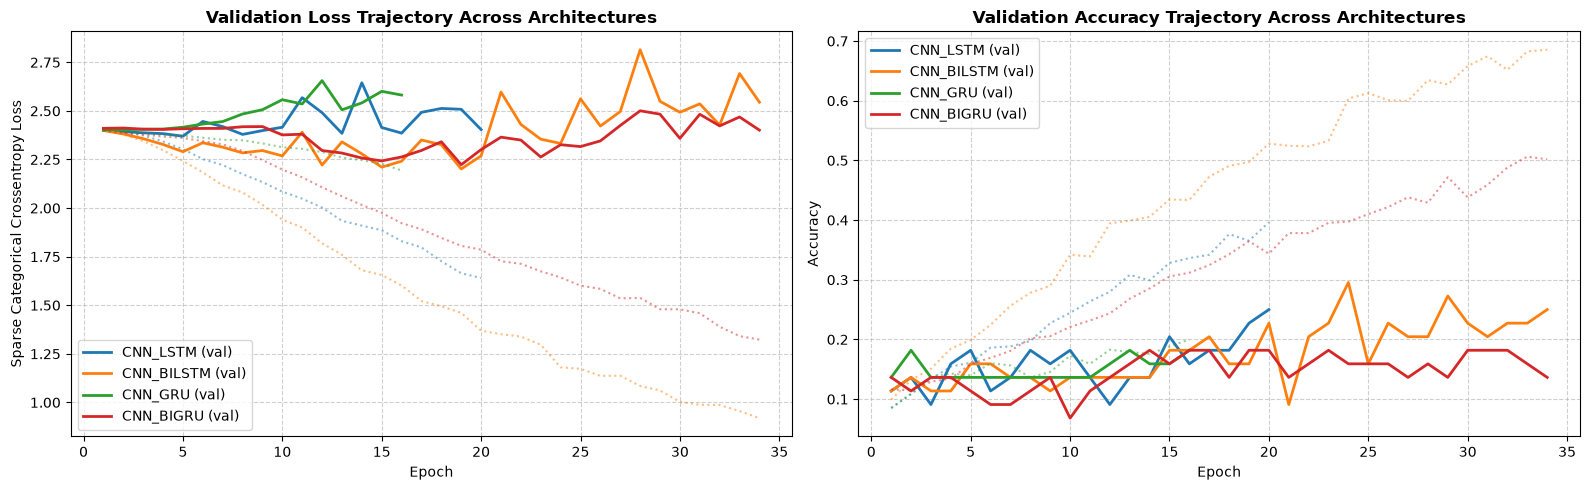

Model comparison curves saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/models/model_comparison_curves.png


In [15]:
# Section 5: Model Comparison & Trajectory Curves
comparison_df = pd.DataFrame(experiment_results)
comp_csv_path = MODELS_DIR / "model_comparison.csv"
comparison_df.to_csv(comp_csv_path, index=False)

print("=" * 75)
print("             CONTROLLED BASELINE BENCHMARK SUMMARY (TEST SET)")
print("=" * 75)
print(comparison_df.to_string(index=False))
print(f"\nSaved comparison CSV to: {comp_csv_path.resolve()}")
print("=" * 75)

# Comparative Training & Validation Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {"cnn_lstm": "#1f77b4", "cnn_bilstm": "#ff7f0e", "cnn_gru": "#2ca02c", "cnn_bigru": "#d62728"}

for m_name in MODELS_TO_RUN:
    h_path = MODELS_DIR / m_name / "training_history.csv"
    if h_path.exists():
        h = pd.read_csv(h_path)
        ep = h.index + 1
        axes[0].plot(ep, h["val_loss"], label=f"{m_name.upper()} (val)", color=colors[m_name], linewidth=2)
        axes[0].plot(ep, h["loss"], linestyle=":", alpha=0.5, color=colors[m_name])
        axes[1].plot(ep, h["val_accuracy"], label=f"{m_name.upper()} (val)", color=colors[m_name], linewidth=2)
        axes[1].plot(ep, h["accuracy"], linestyle=":", alpha=0.5, color=colors[m_name])

axes[0].set_title("Validation Loss Trajectory Across Architectures", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

axes[1].set_title("Validation Accuracy Trajectory Across Architectures", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
curves_path = MODELS_DIR / "model_comparison_curves.png"
plt.savefig(str(curves_path), dpi=150)
plt.show()
print(f"Model comparison curves saved to: {curves_path.resolve()}")